In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('/Users/aksharadarapaneni/data-analyst-portfolio/project-1-ecommerce')

from data_loader import load_data

orders, order_items, order_payments, order_reviews, products, sellers, customers, category_translation, orders_delivered = load_data()

print("All data loaded!")
print("Orders:", orders.shape)
print("Orders delivered:", orders_delivered.shape)

All data loaded!
Orders: (99441, 8)
Orders delivered: (96478, 8)


In [2]:
reference_date=orders_delivered['order_purchase_timestamp'].max()+pd.Timedelta(days=1)
print(reference_date)

2018-08-30 15:00:37


In [3]:
rfm_data=orders_delivered.merge(order_items,on='order_id')

In [8]:
rfm_data=rfm_data.merge(customers,on='customer_id')
rfm_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [9]:
rfm_data.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state'],
      dtype='object')

In [10]:
rfm_table = rfm_data.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', 'max'),
    frequency=('order_id', 'count'),
    monetary=('price', 'sum')
).reset_index()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,18.90
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,180.00


In [12]:
rfm_table['recency'] = (reference_date - rfm_table['recency']).dt.days

In [13]:
rfm_table.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90
2,0000f46a3911fa3c0805444483337064,537,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00


In [14]:
rfm_table['r_score'] = pd.qcut(rfm_table['recency'], 5, labels=[5,4,3,2,1])
rfm_table['f_score'] = pd.qcut(rfm_table['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm_table['m_score'] = pd.qcut(rfm_table['monetary'], 5, labels=[1,2,3,4,5])

In [15]:
rfm_table.head()

,customer_unique_id,recency,frequency,monetary,r_score,f_score,m_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,4,1,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,4,1,1
2,0000f46a3911fa3c0805444483337064,537,1,69.00,1,1,2
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,2,1,1
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,2,1,5


In [16]:
rfm_table['rfm_score'] = rfm_table['r_score'].astype(str) + rfm_table['f_score'].astype(str) + rfm_table['m_score'].astype(str)

In [17]:
rfm_table['rfm_score'].head()

0    414
1    411
2    112
3    211
4    215
Name: rfm_score, dtype: object

In [22]:
rfm_table['segment'] = np.where(rfm_table['r_score'].astype(int) >= 4, 
                        np.where(rfm_table['f_score'].astype(int) >= 4, 'Champion', 'Loyal'),
                        np.where(rfm_table['r_score'].astype(int) >= 3, 'Potential',
                        np.where(rfm_table['r_score'].astype(int) >= 2, 'At Risk', 'Lost')))

In [28]:
segment_counts = rfm_table['segment'].value_counts()

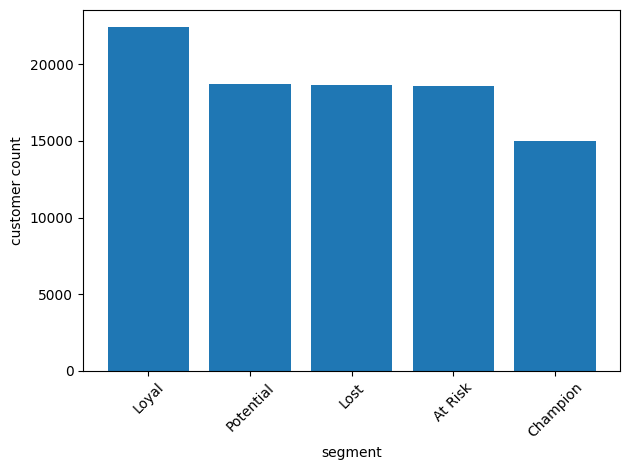

In [29]:
plt.bar(segment_counts.index,segment_counts.values)
plt.xlabel('segment')
plt.ylabel('customer count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
rfm_table.groupby('segment')['monetary'].mean().sort_values(ascending=False)

segment
Champion     160.598818
At Risk      144.565085
Lost         140.469559
Potential    134.057633
Loyal        133.749041
Name: monetary, dtype: float64